# Attention Residuals — Analysis

**Important limitation**
The current attention-residual script logs the same high-level metrics as the baseline, but it does **not** log internal attention-residual diagnostics such as source-selection weights or attention entropy. So this notebook focuses on what is available in W&B today, and explicitly flags extra metrics that would be worth logging next time.

The paper (https://arxiv.org/abs/2603.15031) motivates attention residuals as a replacement for fixed depth-wise accumulation, using softmax attention over earlier representations and recommending zero initialisation of the pseudo-query vectors so the initial mixing is uniform. It also reports that RMSNorm on keys is important, that softmax beats sigmoid, and that block sizes around a small fixed number recover most of the gains of full attention residuals. I incorporate the latter idea in the baseline gpt model in 3 different variants analysing the performance and usefullness of each. 

## Ablation 1 - Full Attention Residual

### Overview

The implemented **Full Attention Residual** replaces the previous encoder/decoder skip-connection mechanism with a **depth-wise attention mixture over all previous transformer-block states**.

Instead of:
- storing only a subset of earlier states as skip connections,
- re-injecting them later in the decoder half,
- and combining them with additional residual mixing inside each block,

the new design does the following:

1. keeps a running **history** of all earlier block representations,
2. applies a **full attention residual module** before each transformer block,
3. uses that attention module to compute the block input as a learned weighted mixture of:
   - the embedding/root representation,
   - every previous block output,
   - the current incoming state.

This is intended to approximate the **Full AttnRes** idea from the paper at the **block level**.

---

### High-level architectural change

In the new implementation, the model no longer has:
- encoder/decoder halves,
- explicit skip stacks,
- skip popping,
- learned skip weights,
- or residual mixing with the original embedding inside each block.

Instead, for every block $l$, the model computes:

$h_l = \sum_{i=0}^{l} \alpha_{i \to l} v_i$

where:
- $v_0$ is the embedding/root state,
- $v_1, \dots, v_{l-1}$ are previous block outputs,
- $v_l$ is the current incoming block state,
- $\alpha_{i \to l}$ are softmax-normalized attention weights over depth.

So each block can selectively retrieve from **all previous depth sources**, not just one previous state or a fixed skip partner.


## Ablation 2: Block Attention Residuals

Standard residual connections aggregate information across depth through a fixed additive rule:

$$
h_l = h_{l-1} + f_{l-1}(h_{l-1})
$$

Unrolling this recurrence shows that each layer receives a uniformly weighted sum of all previous layer outputs. This makes residuals effective as a gradient highway, but it also means that the model has no learned mechanism for deciding which earlier depth representations are most useful for the current layer.

**Attention Residuals** reinterpret residual connections as a form of depth-wise information aggregation. Instead of always summing previous outputs with fixed unit weights, the input to a layer is computed as an attention-weighted combination of earlier representations:

$$
h_l = \sum_i \alpha_{i \rightarrow l} v_i
$$

where the weights \(\alpha_{i \rightarrow l}\) are produced by a softmax attention mechanism over depth. In **Full Attention Residuals**, every layer can attend to the token embedding and to all previous layer outputs individually. This gives the model fine-grained, content-dependent access to the full depth history, but it requires keeping and attending over many intermediate representations.

**Block Attention Residuals** are a more efficient approximation of Full Attention Residuals. Instead of storing every previous layer output separately, the network depth is partitioned into a small number of blocks. Inside each block, layer outputs are accumulated with ordinary summation into a block-level representation. Across blocks, the model applies attention only over:

$$
[b_0, b_1, \dots, b_{n-1}, b_n^{i-1}]
$$

where \(b_0\) is the token embedding, $b_1, \dots, b_{n-1}$ are completed block summaries, and $b_n^{i-1}$ is the current partial sum inside the active block. Thus, each layer still has selective access to earlier depth information, but at block granularity rather than individual-layer granularity.

The main difference is therefore:

- **Full AttnRes:** attends over all previous layer outputs.
- **Block AttnRes:** attends over completed block summaries plus the current intra-block partial sum.

This reduces the memory and communication cost from depending on the total number of layers $L$ to depending on the number of blocks $N$. In the paper, this is described as reducing the residual-history cost from $O(Ld)$ to $O(Nd)$, while preserving most of the benefit of learned depth-wise aggregation.

### Implementation in this GPT model

In this implementation, the original Full AttnRes modules are replaced by `BlockAttentionResidual` modules. Each module computes a softmax over the available block-level sources using a learned pseudo-query vector and RMS-normalized keys:

$$
\alpha_i =
\text{softmax}
\left(
w_l^\top \text{RMSNorm}(v_i)
\right)
$$

The RMSNorm prevents sources with larger hidden-state magnitude from dominating the attention logits only because of scale. The pseudo-query vector is initialized to zero, so at the beginning of training the attention distribution is approximately uniform over the available sources.

Because this GPT architecture is decoder-only, the requested two-block setting is implemented as two contiguous depth blocks across the decoder stack, rather than as separate encoder and decoder blocks. Each transformer block contributes two depth sublayers: one self-attention sublayer and one MLP sublayer. Therefore, Block AttnRes is applied before both the self-attention and MLP computations, while their outputs are accumulated into the current partial block representation.

At the end of the model, a final Block AttnRes aggregation combines the completed block summaries before the final normalization and language-model head. This keeps the final representation consistent with the block-wise residual formulation rather than reverting to a standard residual stream.

## Ablation 3 - Skip Attention

I thus created a simpler version of attention residuals that only replaces the **encoder/decoder skip bridge** with an attention-style aggregation, while leaving the internal transformer residual stream unchanged. Therefore, I first analyse a **partial attention-residual adaptation**, not a fully paper-faithful Block AttnRes model, by removing fixed skip connections and instead using an attention mechanism to reweight the inputs from the skip stack while keeping the residual mixing of Transformer Blocks unchanged. Conceptually, for decoder step $i$, instead of:

$$x \leftarrow x + w_i \odot \text{skip}_i$$

I now do:

$$V = [\text{skip}_1, \dots, \text{skip}_k, x]$$

$$K = \mathrm{RMSNorm}(V)$$

$$\alpha = \mathrm{softmax}(q^\top K)$$

$$x \leftarrow \sum_j \alpha_j V_j$$

where $q$ is the learned vector stored in `self.proj.weight`.

More specifically, I added a new module `BlockAttentionResidual` which:

* takes a list of stored encoder states plus the current decoder state,
* stacks them as depth-wise sources,
* applies RMSNorm to the sources,
* computes one learned scalar attention logit per source using a learned query-like vector,
* softmaxes over the source dimension,
* returns the weighted sum.

In `GPT.forward`, I thus replaced the decoder-side additive skip connection:

* **Old behavior:** `x = x + self.skip_weights[i] * skips.pop()`
* **New behavior:** `x = self.skip_attn_res[i](skips, x)`

So the decoder now aggregates:

* all currently available encoder skip states in `skips`
* plus the current decoder hidden state `x`

using softmax attention over those sources, instead of a single weighted additive skip.

## Importing Runs' Data

In [1]:
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import wandb
import importlib
import utils

importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api(timeout=60)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\flamo\_netrc.


In [2]:
BASELINE_REGEXES = [
    r"^golf_baseline_antonio_new",
]

ATTNRES_REGEXES = [
    r"^Full_Attn_Res",
    r"^skip_attn",
    r"^skip_attn_v1",
    r"^block_attn_res"
]

# Optional hard filters. Leave as None to disable.
REQUIRE_NUM_LAYERS = None
REQUIRE_MODEL_DIM  = None
REQUIRE_SEQ_LEN    = None

MAX_RUNS_PER_QUERY = 200

In [3]:
def fetch_runs_by_regex(regexes, *, entity=ENTITY, project=PROJECT, max_runs=MAX_RUNS_PER_QUERY):
    out = []
    # seen = set()
    for rx in regexes:
        runs = api.runs(
            f"{entity}/{project}", filters={"display_name": {"$regex": rx}},
        )
        # for i in runs: print(i.id)
        for run in runs:
            out.append(run)
            # seen.add(run.id)
    return out


def passes_shape_filters(run):
    cfg = run.config
    checks = [
        REQUIRE_NUM_LAYERS is None or cfg.get("num_layers") == REQUIRE_NUM_LAYERS,
        REQUIRE_MODEL_DIM is None or cfg.get("model_dim") == REQUIRE_MODEL_DIM,
        REQUIRE_SEQ_LEN is None or cfg.get("train_seq_len") == REQUIRE_SEQ_LEN,
    ]
    return all(checks)

def strip_seed_suffix(name: str) -> str:
    name = re.sub(r"_seed\d+$", "", name)
    name = re.sub(r"-seed\d+$", "", name)
    return name

def safe_get_summary(run, key, default=np.nan):
    return run.summary._json_dict.get(key, default)

def classify_variant(run):
    cfg = run.config
    name = (run.name or run.display_name or "")
    lower = name.lower()
    if any(k in lower for k in ["full_attn_res", "attn_res"]):
        return "Full Attention residual"
    if any(k in lower for k in ["skip_attn"]):
        return "Skip Attention"
    if "baseline" in lower:
        return "Baseline"
    return "Unknown"

In [4]:
def run_to_row(run, mode="auto", forced_variant=None):
    cfg = run.config
    s = run.summary._json_dict
    display_name = run.display_name or run.name

    if mode not in {"auto", "baseline", "attn"}:
        raise ValueError(f"Unsupported mode={mode!r}. Use 'auto', 'baseline', or 'attn'.")

    variant = forced_variant or classify_variant(run)

    # Detect whether skip-attn tracking is present
    has_skip_attn = any(
        k.startswith("skip_attn/") or k.startswith("grad_norm/skip_attn/") or k.startswith("hidden_norm/")
        for k in s.keys()
    )

    include_attn = (mode == "attn") or (mode == "auto" and has_skip_attn)

    row = {
        "run_id": run.id,
        "run_name": run.name,
        "display_name": display_name,
        "group": strip_seed_suffix(display_name),
        "variant": variant,
        "seed": cfg.get("seed"),
        "num_layers": cfg.get("num_layers"),
        "model_dim": cfg.get("model_dim"),
        "num_heads": cfg.get("num_heads"),
        "num_kv_heads": cfg.get("num_kv_heads"),
        "train_seq_len": cfg.get("train_seq_len"),
        "train_batch_tokens": cfg.get("train_batch_tokens"),
        "iterations": cfg.get("iterations"),
        "warmup_steps": cfg.get("warmup_steps"),
        "max_wallclock_seconds": cfg.get("max_wallclock_seconds"),
        "qk_gain_init": cfg.get("qk_gain_init"),
        "final_val_bpb": s.get("final_val_bpb"),
        "final_val_loss": s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
        "quant_compression_ratio": s.get("quant_compression_ratio"),
    }

    if include_attn:
        # Run-level config for the tracking script
        row.update({
            "attn_diag_log_every": cfg.get("attn_diag_log_every"),
            "attn_snapshot_every": cfg.get("attn_snapshot_every"),
        })

        # Aggregate skip-attn metrics commonly logged in summary
        row.update({
            "skip_attn_entropy_mean_over_layers": s.get("skip_attn/entropy_mean_over_layers"),
            "skip_attn_decoder_mass_mean_over_layers": s.get("skip_attn/decoder_mass_mean_over_layers"),
            "skip_attn_encoder_mass_mean_over_layers": s.get("skip_attn/encoder_mass_mean_over_layers"),
            "grad_norm_skip_attn_global": s.get("grad_norm/skip_attn/global"),
            "grad_norm_skip_attn_num_params_with_grad": s.get("grad_norm/skip_attn/num_params_with_grad"),
        })

        # Pull all flat scalar diagnostics created by skip_attn_wandb_tracking
        # so newly added layer/source metrics are not lost.
        for k, v in s.items():
            if (
                k.startswith("skip_attn/")
                or k.startswith("grad_norm/skip_attn/")
                or k.startswith("hidden_norm/")
            ):
                safe_key = (
                    k.replace("/", "__")
                     .replace(" ", "_")
                     .replace("-", "_")
                )
                row[safe_key] = v

        # Keep direct references to W&B table/media objects if present in summary
        # e.g. skip_attn/source_weight_snapshot
        if "skip_attn/source_weight_snapshot" in s:
            row["skip_attn_source_weight_snapshot"] = s["skip_attn/source_weight_snapshot"]

    return row

def download_run_history(run, mode="auto", samples=5000):
    """
    Download history rows for a run.
    For attention runs, keep all skip_attn / grad_norm / hidden_norm metrics.
    """
    hist = run.history(samples=samples)

    if mode == "baseline":
        keep = [
            "train_loss",
            "val_loss",
            "val_bpb",
            "lr_scale",
            "tokens_seen",
            "final_val_loss",
            "final_val_bpb",
        ]
        keep = [c for c in keep if c in hist.columns]
        return hist[keep].copy()

    if mode == "attn":
        keep = [
            c for c in hist.columns
            if (
                c in {
                    "train_loss", "val_loss", "val_bpb", "lr_scale", "tokens_seen",
                    "final_val_loss", "final_val_bpb", 
                }
                or c.startswith("skip_attn/")
                or c.startswith("grad_norm/skip_attn/")
                or c.startswith("hidden_norm/")
            )
        ]
        return hist[keep].copy()

    # auto
    has_attn_cols = any(
        c.startswith("skip_attn/") or c.startswith("grad_norm/skip_attn/") or c.startswith("hidden_norm/")
        for c in hist.columns
    )
    return download_run_history(run, mode="attn" if has_attn_cols else "baseline", samples=samples)

def get_skip_attn_snapshot_table(run):
    s = run.summary._json_dict
    return s.get("skip_attn/source_weight_snapshot")

In [5]:
baseline_runs_all = fetch_runs_by_regex(BASELINE_REGEXES)
attnres_runs_all  = fetch_runs_by_regex(ATTNRES_REGEXES)

baseline_runs = [r for r in baseline_runs_all if passes_shape_filters(r)]
attnres_runs  = [r for r in attnres_runs_all if passes_shape_filters(r)]

print(f"Baseline runs found:          {len(baseline_runs)}")
print(f"Attention-residual runs found:{len(attnres_runs)}")

if baseline_runs:
    print("Sample baseline names:")
    for r in baseline_runs[:5]:
        print("  -", r.display_name)

if attnres_runs:
    print("Sample attention-residual names:")
    for r in attnres_runs[:15]:
        print("  -", r.display_name)

Baseline runs found:          3
Attention-residual runs found:15
Sample baseline names:
  - golf_baseline_antonio_new_seed1337
  - golf_baseline_antonio_new_seed42
  - golf_baseline_antonio_new_seed123
Sample attention-residual names:
  - Full_Attn_Res_seed1337
  - Full_Attn_Res_seed42
  - Full_Attn_Res_seed123
  - Skip_Attn_v1_seed1337
  - Skip_Attn_v1_seed42
  - Skip_Attn_v1_seed123
  - skip_attn_seed1337
  - skip_attn_seed42
  - skip_attn_seed123
  - Skip_Attn_v1_seed1337
  - Skip_Attn_v1_seed42
  - Skip_Attn_v1_seed123
  - block_attn_res_seed1337
  - block_attn_res_seed42
  - block_attn_res_seed123


## Baseline runs

In [6]:
df_base = pd.DataFrame([run_to_row(r, forced_variant="Baseline") for r in baseline_runs])
if not df_base.empty:
    df_base = df_base.sort_values(["group", "seed"], na_position="last").reset_index(drop=True)
    BASE_BPB_MEAN = df_base["final_val_bpb"].dropna().mean()
    BASE_BPB_STD  = df_base["final_val_bpb"].dropna().std()
    display(df_base[[
        "display_name", "seed", "num_layers", "model_dim", "train_seq_len",
        "final_val_bpb", "final_val_loss", "quant_file_bytes"
    ]])
    print(f"Baseline mean final_val_bpb: {BASE_BPB_MEAN:.4f}")
    print(f"Baseline std final_val_bpb : {BASE_BPB_STD:.4f}")
else:
    BASE_BPB_MEAN = np.nan
    BASE_BPB_STD = np.nan
    print("No baseline runs found with the current regex/filter settings.")

,display_name,seed,num_layers,model_dim,train_seq_len,final_val_bpb,final_val_loss,quant_file_bytes
0,golf_baseline_antonio_new_seed42,42,9,512,1024,1.311465,2.214354,15782427
1,golf_baseline_antonio_new_seed123,123,9,512,1024,1.309002,2.210195,15785894
2,golf_baseline_antonio_new_seed1337,1337,9,512,1024,1.309833,2.211598,15776355


Baseline mean final_val_bpb: 1.3101
Baseline std final_val_bpb : 0.0013


## Attention-Residual runs

In [7]:
df_attn = pd.DataFrame([run_to_row(r, forced_variant="Attention residual") for r in attnres_runs])

if not df_attn.empty:
    df_attn = df_attn.sort_values(["group", "seed"], na_position="last").reset_index(drop=True)

    display(df_attn[[
        "display_name", "group", "seed", "num_layers", "model_dim", "train_seq_len",
        "qk_gain_init", "final_val_bpb", "final_val_loss", "quant_file_bytes"
    ]])

,display_name,group,seed,num_layers,model_dim,train_seq_len,qk_gain_init,final_val_bpb,final_val_loss,quant_file_bytes
0,Full_Attn_Res_seed42,Full_Attn_Res,42,9,512,1024,1.5,1.323845,2.235257,15675596
1,Full_Attn_Res_seed123,Full_Attn_Res,123,9,512,1024,1.5,1.335716,2.255301,15572720
2,Full_Attn_Res_seed1337,Full_Attn_Res,1337,9,512,1024,1.5,1.324816,2.236896,15718975
3,Skip_Attn_v1_seed42,Skip_Attn_v1,42,9,512,1024,1.5,1.306490,2.205954,15793365
4,Skip_Attn_v1_seed42,Skip_Attn_v1,42,9,512,1024,1.5,1.306490,2.205954,15793365
5,Skip_Attn_v1_seed123,Skip_Attn_v1,123,9,512,1024,1.5,1.307492,2.207645,15790535
6,Skip_Attn_v1_seed123,Skip_Attn_v1,123,9,512,1024,1.5,1.307492,2.207645,15790535
7,Skip_Attn_v1_seed1337,Skip_Attn_v1,1337,9,512,1024,1.5,1.305216,2.203802,15789786
8,Skip_Attn_v1_seed1337,Skip_Attn_v1,1337,9,512,1024,1.5,1.305216,2.203802,15789786
9,block_attn_res_seed42,block_attn_res,42,9,512,1024,1.5,1.519204,2.565112,13830186


### Grouped Summary of Attention Residuals Ablations

In [8]:
if not df_attn.empty:
    summary = (
        df_attn.groupby("group", dropna=False)
        .agg(
            seeds=("seed", lambda s: ", ".join(map(str, sorted([x for x in s.dropna().unique()]))) if s.notna().any() else "?"),
            n_runs=("run_id", "count"),
            final_val_bpb_mean=("final_val_bpb", "mean"),
            final_val_bpb_std=("final_val_bpb", "std"),
            final_val_loss_mean=("final_val_loss", "mean"),
            quant_file_bytes_mean=("quant_file_bytes", "mean"),
            model_dim=("model_dim", "first"),
            qk_gain_init=("qk_gain_init", "first"),
        )
        .sort_values("final_val_bpb_mean", ascending=True)
        .reset_index()
    )
    if not np.isnan(BASE_BPB_MEAN):
        summary["Δ vs baseline mean"] = BASE_BPB_MEAN - summary["final_val_bpb_mean"]
    display(summary)
else:
    print("No grouped summary available.")

,group,seeds,n_runs,final_val_bpb_mean,final_val_bpb_std,final_val_loss_mean,quant_file_bytes_mean,model_dim,qk_gain_init,Δ vs baseline mean
0,Skip_Attn_v1,"42, 123, 1337",6,1.306399,0.001020,2.205800,1.579123e+07,512,1.5,0.003701
1,skip_attn,"42, 123, 1337",3,1.309269,0.001445,2.210646,1.578789e+07,512,1.5,0.000831
2,Full_Attn_Res,"42, 123, 1337",3,1.328126,0.006592,2.242485,1.565576e+07,512,1.5,-0.018026
3,block_attn_res,"42, 123, 1337",3,1.461910,0.050044,2.468374,1.497764e+07,512,1.5,-0.151810


### Best attention-residual run

In [9]:
if not df_attn.empty and df_attn["final_val_bpb"].notna().any():
    best = df_attn.loc[df_attn["final_val_bpb"].idxmin()]
    print(f"Best run         : {best['display_name']}")
    print(f"Group            : {best['group']}")
    print(f"Seed             : {best['seed']}")
    print(f"final_val_bpb    : {best['final_val_bpb']:.4f}")
    print(f"final_val_loss   : {best['final_val_loss']:.4f}")
    if not np.isnan(BASE_BPB_MEAN):
        delta = BASE_BPB_MEAN - best["final_val_bpb"]
        print(f"Δ vs baseline μ  : {delta:+.4f} bpb")
    if pd.notna(best.get("quant_file_bytes", np.nan)):
        print(f"quant_file_bytes : {best['quant_file_bytes'] / 1e6:.2f} MB")
else:
    print("No valid final_val_bpb available.")

Best run         : Skip_Attn_v1_seed1337
Group            : Skip_Attn_v1
Seed             : 1337
final_val_bpb    : 1.3052
final_val_loss   : 2.2038
Δ vs baseline μ  : +0.0049 bpb
quant_file_bytes : 15.79 MB


### Final val_bpb — grouped bar chart

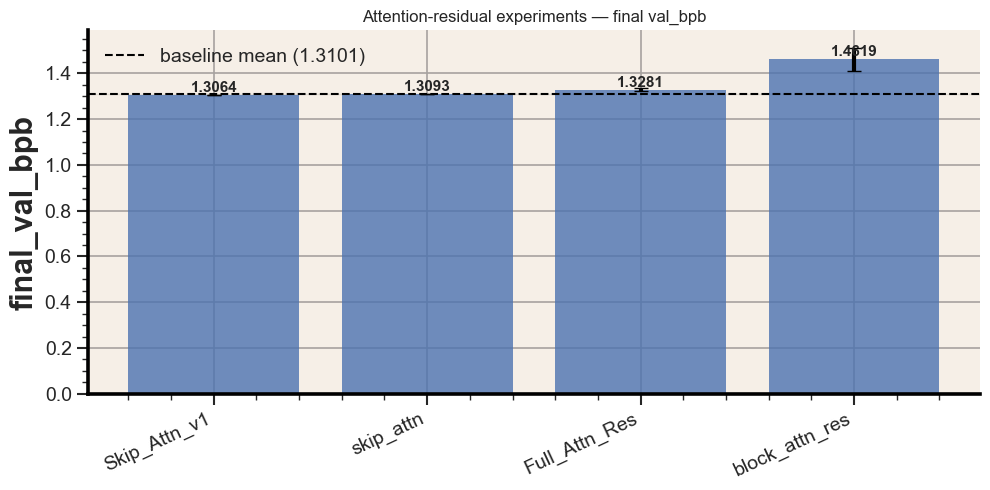

In [10]:
if not df_attn.empty:
    plot_df = (
        df_attn.groupby("group", dropna=False)["final_val_bpb"]
        .agg(["mean", "std", "count"])
        .sort_values("mean", ascending=True)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    xs = np.arange(len(plot_df))
    ax.bar(xs, plot_df["mean"], color=PALETTE[0], alpha=0.8, zorder=2)
    std_vals = plot_df["std"].fillna(0).values
    ax.errorbar(xs, plot_df["mean"], yerr=std_vals, fmt="none", color="black", capsize=5, zorder=3)

    for i, row in plot_df.iterrows():
        ax.text(i, row["mean"] + 0.00025, f"{row['mean']:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

    if not np.isnan(BASE_BPB_MEAN):
        ax.axhline(BASE_BPB_MEAN, color="black", linewidth=1.5, linestyle="--", label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
        if not np.isnan(BASE_BPB_STD):
            ax.axhspan(BASE_BPB_MEAN - BASE_BPB_STD, BASE_BPB_MEAN + BASE_BPB_STD, color="black", alpha=0.08)

    ax.set_xticks(xs)
    ax.set_xticklabels(plot_df["group"], rotation=25, ha="right")
    ax.set_ylabel("final_val_bpb")
    ax.set_title("Attention-residual experiments — final val_bpb")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No plot: no attention-residual runs.")

## Learning curves

In [11]:
METRIC_KEYS = ["val_bpb", "val_loss", "train_loss"]

attn_histories = {}
for run in attnres_runs:
    attn_histories[run.id] = download_run_history(run)

base_histories = {}
for run in baseline_runs:
    base_histories[run.id] = download_run_history(run)

print(f"Histories fetched for attn-res runs: {sum(not h.empty for h in attn_histories.values())}")
print(f"Histories fetched for baseline runs : {sum(not h.empty for h in base_histories.values())}")

Histories fetched for attn-res runs: 12
Histories fetched for baseline runs : 3


In [12]:
# helper functions

def strip_seed_suffix(name):
    return re.sub(r"_seed\d+$", "", name or "")

def run_label(run):
    return run.display_name or run.name or run.id

def run_group(run):
    return strip_seed_suffix(run_label(run))

def history_metric_with_step_from_tokens(run, hist, metric):
    if hist is None or hist.empty:
        return pd.DataFrame()

    df = hist.copy()
    if metric not in df.columns or "tokens_seen" not in df.columns:
        return pd.DataFrame()

    train_batch_tokens = run.config.get("train_batch_tokens")
    if not train_batch_tokens:
        return pd.DataFrame()

    df["tokens_seen"] = pd.to_numeric(df["tokens_seen"], errors="coerce")
    df[metric] = pd.to_numeric(df[metric], errors="coerce")
    df = df.dropna(subset=["tokens_seen", metric]).copy()
    if df.empty:
        return pd.DataFrame()

    df["step"] = df["tokens_seen"] / train_batch_tokens
    df = df.sort_values("step").drop_duplicates(subset=["step"], keep="last")
    return df[["step", metric]].copy()

def build_group_curves(runs, histories, metric):
    rows = []
    for run in runs:
        hist = histories.get(run.id)
        df = history_metric_with_step_from_tokens(run, hist, metric)
        if df.empty:
            continue
        tmp = df.copy()
        tmp["group"] = run_group(run)
        tmp["seed"] = run.config.get("seed")
        rows.append(tmp)

    if not rows:
        return pd.DataFrame(columns=["group", "step", "mean", "std", "n"])

    out = pd.concat(rows, ignore_index=True)
    grouped = (
        out.groupby(["group", "step"], as_index=False)[metric]
        .agg(mean="mean", std="std", n="count")
        .reset_index(drop=True)
    )
    grouped["std"] = grouped["std"].fillna(0.0)
    return grouped

def plot_grouped_metric(ax, runs_a, histories_a, runs_b, histories_b, metric, ylabel=None,
                        label_a="attn_residuals", label_b="baseline", init_step=1,
                        xlabel_pad=12, ylabel_pad=12, title_pad=24):
    curves_a = build_group_curves(runs_a, histories_a, metric)
    curves_b = build_group_curves(runs_b, histories_b, metric)

    if not curves_a.empty:
        for group in curves_a["group"].unique():
            g = curves_a[curves_a["group"] == group].sort_values("step")
            x = g["step"][init_step:].to_numpy()
            y = g["mean"][init_step:].to_numpy()
            s = g["std"][init_step:].to_numpy()
            ax.plot(x, y, label=f"{label_a} | {group}")
            ax.fill_between(x, y - s, y + s, alpha=0.18)

    if not curves_b.empty:
        for group in curves_b["group"].unique():
            g = curves_b[curves_b["group"] == group].sort_values("step")
            x = g["step"][init_step:].to_numpy()
            y = g["mean"][init_step:].to_numpy()
            s = g["std"][init_step:].to_numpy()
            ax.plot(x, y, linestyle="--", label=f"{label_b} | {group}")
            ax.fill_between(x, y - s, y + s, alpha=0.12)

    ax.set_xlabel("step", labelpad=xlabel_pad)

    if metric == "train_loss":
        ax.set_xlim(500, 5000)
        ax.set_ylim(0, 3)

    ax.set_ylabel(ylabel or metric, labelpad=ylabel_pad)
    ax.set_title(metric, pad=title_pad)
    ax.grid(True, alpha=0.3)

def get_summary_value(run, key, default=np.nan):
    try:
        return run.summary._json_dict.get(key, default)
    except Exception:
        return default

def build_run_summary_df(runs, kind):
    rows = []
    for run in runs:
        s = run.summary._json_dict
        rows.append({
            "kind": kind,
            "group": run_group(run),
            "seed": run.config.get("seed"),
            "run_name": run_label(run),
            "final_val_bpb": s.get("final_val_bpb", np.nan),
            "final_val_loss": s.get("final_val_loss", np.nan),
            "quant_file_bytes": s.get("quant_file_bytes", np.nan),
            "quant_compression_ratio": s.get("quant_compression_ratio", np.nan),
            "skip_attn_entropy_mean_over_layers": s.get("skip_attn/entropy_mean_over_layers", np.nan),
            "skip_attn_decoder_mass_mean_over_layers": s.get("skip_attn/decoder_mass_mean_over_layers", np.nan),
            "skip_attn_encoder_mass_mean_over_layers": s.get("skip_attn/encoder_mass_mean_over_layers", np.nan),
            "grad_norm_skip_attn_global": s.get("grad_norm/skip_attn/global", np.nan),
        })
    return pd.DataFrame(rows)

def aggregate_final(df, value_col):
    g = (
        df.groupby(["kind", "group"], as_index=False)[value_col]
        .agg(mean="mean", std="std", n="count")
    )
    g["std"] = g["std"].fillna(0.0)
    return g

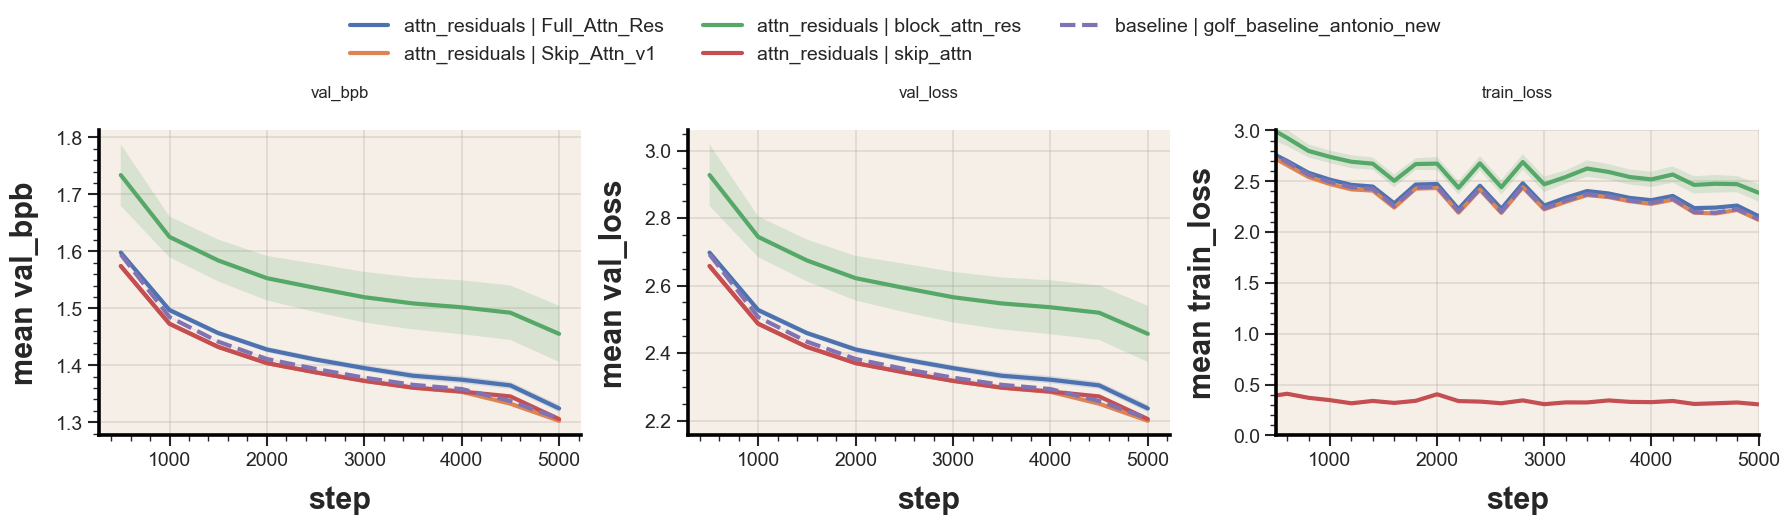

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

INITIAL_STEP = 1 #after 500 iter

plot_grouped_metric(
    axes[0], attnres_runs, attn_histories, baseline_runs, base_histories,
    metric="val_bpb", ylabel="mean val_bpb", init_step=INITIAL_STEP,
)
plot_grouped_metric(
    axes[1], attnres_runs, attn_histories, baseline_runs, base_histories,
    metric="val_loss", ylabel="mean val_loss",  init_step=INITIAL_STEP
)
plot_grouped_metric(
    axes[2], attnres_runs, attn_histories, baseline_runs, base_histories,
    metric="train_loss", ylabel="mean train_loss", init_step=INITIAL_STEP
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.06),  # move legend slightly upward
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

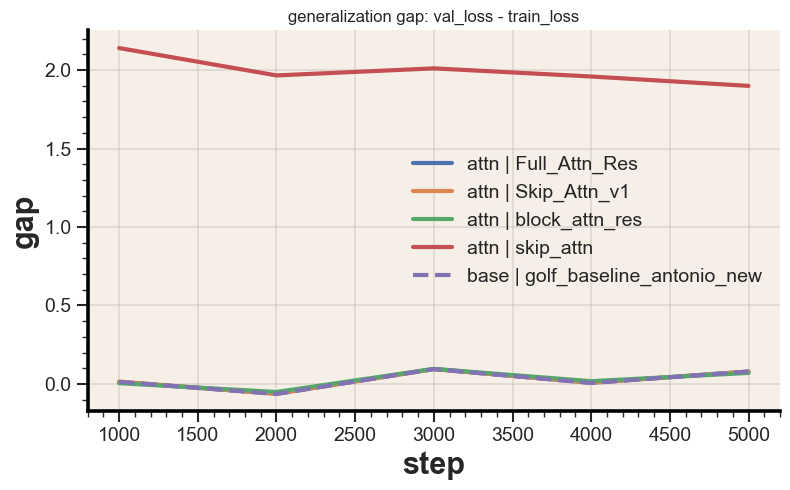

In [14]:
def build_gap_curves(runs, histories):
    rows = []
    for run in runs:
        h_train = history_metric_with_step_from_tokens(run, histories.get(run.id), "train_loss")
        h_val   = history_metric_with_step_from_tokens(run, histories.get(run.id), "val_loss")
        if h_train.empty or h_val.empty:
            continue
        merged = pd.merge(h_train, h_val, on="step", how="inner", suffixes=("_train", "_val"))
        if merged.empty:
            continue
        merged["gap"] = merged["val_loss"] - merged["train_loss"]
        merged["group"] = run_group(run)
        merged["seed"] = run.config.get("seed")
        rows.append(merged[["group", "seed", "step", "gap"]])
    if not rows:
        return pd.DataFrame(columns=["group", "step", "mean", "std"])
    out = pd.concat(rows, ignore_index=True)
    g = out.groupby(["group", "step"], as_index=False)["gap"].agg(mean="mean", std="std")
    g["std"] = g["std"].fillna(0.0)
    return g

gap_attn = build_gap_curves(attnres_runs, attn_histories)
gap_base = build_gap_curves(baseline_runs, base_histories)

fig, ax = plt.subplots(figsize=(8, 5))
for group in gap_attn["group"].unique():
    g = gap_attn[gap_attn["group"] == group].sort_values("step")
    ax.plot(g["step"], g["mean"], label=f"attn | {group}")
    ax.fill_between(g["step"], g["mean"] - g["std"], g["mean"] + g["std"], alpha=0.18)
for group in gap_base["group"].unique():
    g = gap_base[gap_base["group"] == group].sort_values("step")
    ax.plot(g["step"], g["mean"], linestyle="--", label=f"base | {group}")
    ax.fill_between(g["step"], g["mean"] - g["std"], g["mean"] + g["std"], alpha=0.12)

ax.set_title("generalization gap: val_loss - train_loss")
ax.set_xlabel("step")
ax.set_ylabel("gap")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Quantization and final val_bpb

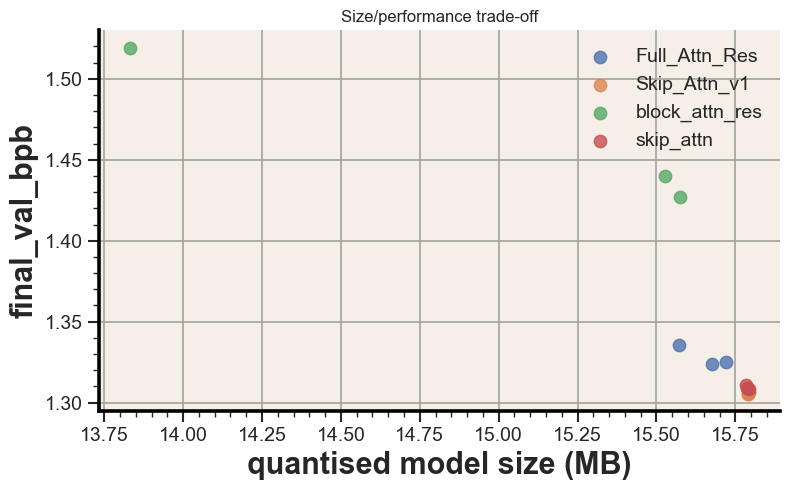

In [15]:
if not df_attn.empty and df_attn["quant_file_bytes"].notna().any():
    fig, ax = plt.subplots(figsize=(8, 5))
    for group, g in df_attn.groupby("group"):
        ax.scatter(g["quant_file_bytes"] / 1e6, g["final_val_bpb"], s=80, alpha=0.8, label=group)

    ax.set_xlabel("quantised model size (MB)")
    ax.set_ylabel("final_val_bpb")
    ax.set_title("Size/performance trade-off")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()
else:
    print("No size/performance scatter available.")

Attn runs with quantization delta: 15
Baseline runs with quantization delta: 3


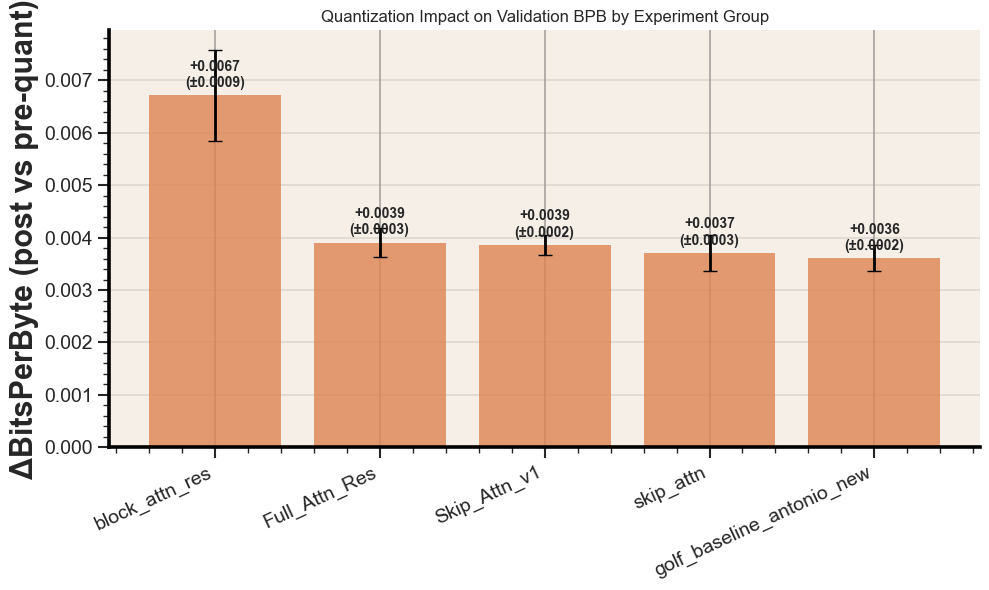


Detailed aggregation:


,group,mean,std,count
2,block_attn_res,0.006712,0.000861,3
0,Full_Attn_Res,0.003906,0.000279,3
1,Skip_Attn_v1,0.003861,0.000186,6
4,skip_attn,0.003710,0.000344,3
3,golf_baseline_antonio_new,0.003610,0.000247,3


In [16]:
def build_quantization_delta_df(runs, histories):
    """
    For each run, compute the difference between:
    - final_val_bpb (post-quantization, from summary)
    - last_val_bpb (pre-quantization, from history)
    """
    rows = []
    for run in runs:
        hist = histories.get(run.id)
        s = run.summary._json_dict
        
        final_bpb = s.get("final_val_bpb")
        if final_bpb is None:
            continue
        
        # Get last val_bpb from history
        if hist is not None and not hist.empty and "val_bpb" in hist.columns:
            last_val_bpb = hist["val_bpb"].dropna().iloc[-1] if len(hist["val_bpb"].dropna()) > 0 else None
        else:
            last_val_bpb = None
        
        if last_val_bpb is None:
            continue
        
        delta = final_bpb - last_val_bpb
        rows.append({
            "group": run_group(run),
            "seed": run.config.get("seed"),
            "run_name": run_label(run),
            "delta_bpb": delta,
            "final_val_bpb": final_bpb,
            "last_val_bpb": last_val_bpb,
        })
    
    if not rows:
        return pd.DataFrame(columns=["group", "seed", "run_name", "delta_bpb"])
    
    return pd.DataFrame(rows)


def plot_quantization_delta(attn_df, base_df, figsize=(10, 6)):
    # Add a 'kind' column to distinguish between attn and baseline
    attn_df_copy = attn_df.copy()
    attn_df_copy["kind"] = "Attention Residual"
    
    base_df_copy = base_df.copy()
    base_df_copy["kind"] = "Baseline"
    
    # Combine
    combined = pd.concat([attn_df_copy, base_df_copy], ignore_index=True)
    
    if combined.empty:
        print("No data available for quantization delta plot.")
        return
    
    # Aggregate by group (and kind if both present)
    agg_df = (
        combined.groupby("group")["delta_bpb"]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
    )
    agg_df = agg_df.sort_values("mean", ascending=False)
    
    fig, ax = plt.subplots(figsize=figsize)
    xs = np.arange(len(agg_df))
    
    ax.bar(xs, agg_df["mean"], color=PALETTE[1], alpha=0.8, zorder=2)
    ax.errorbar(
        xs, agg_df["mean"],
        yerr=agg_df["std"].fillna(0),
        fmt="none", color="black", capsize=5, elinewidth=2, zorder=3
    )
    
    # Add value labels on bars
    for i, (idx, row) in enumerate(agg_df.iterrows()):
        label = f"{row['mean']:+.4f}"
        if row["count"] > 1:
            label += f"\n(±{row['std']:.4f})"
        ax.text(i, row["mean"] + 0.0001, label, ha="center", va="bottom", fontsize=10, fontweight="bold")
    
    ax.set_xticks(xs)
    ax.set_xticklabels(agg_df["group"], rotation=25, ha="right")
    ax.set_ylabel("ΔBitsPerByte (post vs pre-quant)")
    ax.set_title("Quantization Impact on Validation BPB by Experiment Group")
    # ax.axhline(0, color="red", linewidth=1, linestyle="--", alpha=0.7, label="No degradation")
    ax.grid(True, alpha=0.3, axis="y")
    
    plt.tight_layout()
    plt.show()
    
    return agg_df


# Compute delta DataFrames for both attn and baseline runs
delta_attn = build_quantization_delta_df(attnres_runs, attn_histories)
delta_base = build_quantization_delta_df(baseline_runs, base_histories)

print(f"Attn runs with quantization delta: {len(delta_attn)}")
print(f"Baseline runs with quantization delta: {len(delta_base)}")

# Create the plot
if not delta_attn.empty or not delta_base.empty:
    agg_result = plot_quantization_delta(delta_attn, delta_base)
    print("\nDetailed aggregation:")
    display(agg_result)
else:
    print("No quantization data available for plotting.")

## Internal model analysis

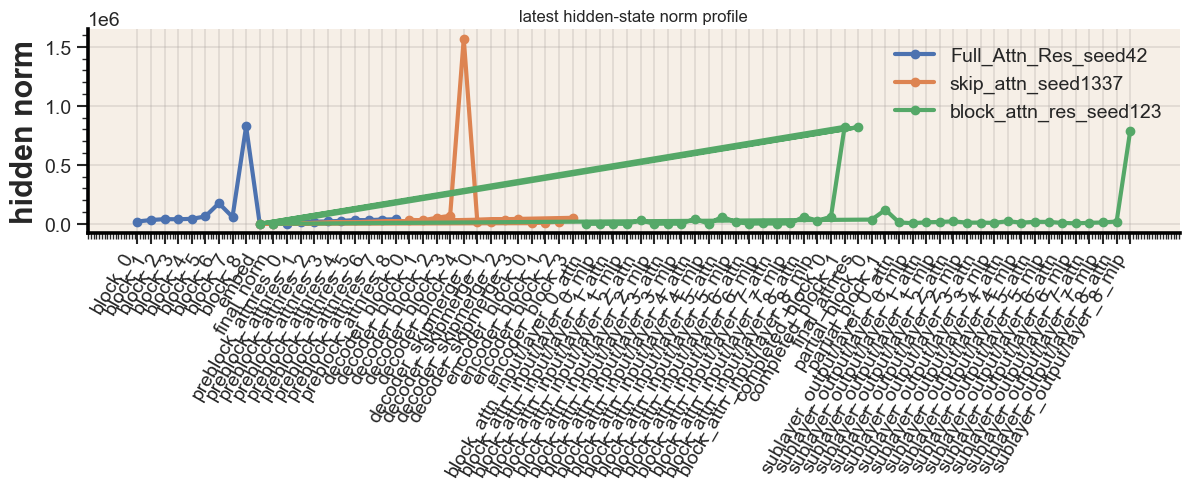

In [17]:
def extract_latest_hidden_norm_profile(run):
    s = run.summary._json_dict
    profile = []
    for k, v in s.items():
        if k.startswith("hidden_norm/") and k.endswith("_mean"):
            name = k[len("hidden_norm/"):-len("_mean")]
            profile.append((name, float(v)))
    if not profile:
        return pd.DataFrame(columns=["name", "value"])
    df = pd.DataFrame(profile, columns=["name", "value"])
    return df.sort_values("name")

# Compare one representative run from each group
summary_attn = build_run_summary_df(attnres_runs, "attn")
summary_base = build_run_summary_df(baseline_runs, "base")

rep_runs = []
for group in summary_attn["group"].dropna().unique():
    candidates = [r for r in attnres_runs if run_group(r) == group]
    if candidates:
        rep_runs.append(min(candidates, key=lambda r: get_summary_value(r, "final_val_bpb", np.inf)))
for group in summary_base["group"].dropna().unique():
    candidates = [r for r in baseline_runs if run_group(r) == group]
    if candidates:
        rep_runs.append(min(candidates, key=lambda r: get_summary_value(r, "final_val_bpb", np.inf)))

plt.figure(figsize=(12, 5))
for run in rep_runs:
    prof = extract_latest_hidden_norm_profile(run)
    if prof.empty:
        continue
    plt.plot(prof["name"], prof["value"], marker="o", label=run_label(run))
plt.xticks(rotation=60, ha="right")
plt.ylabel("hidden norm")
plt.title("latest hidden-state norm profile")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Interpreting the current results

The current implementation changes only the **bridge between encoder and decoder halves** by replacing the scalar-weighted skip reuse with a softmax-weighted aggregation over stored encoder skip states plus the current decoder state. The rest of the transformer block stays the same as in the original script, including the standard residual updates inside each block. In the original training script, this bridge was a simple additive skip weighted by `skip_weights`; the patched variant swaps it for a learned attention-style residual module, but still logs the same top-level W&B metrics as before. fileciteturn1file1L655-L671

## Optional: quick experiment shortlist

If you want the next three experiments to be the most informative per unit effort, I would do them in this order:

1. **Zero-init query/projection + 3 seeds**  
2. **Softmax vs sigmoid vs old scalar skip bridge**  
3. **Bridge-only attention residual vs true in-block residual replacement**

That sequence tells you whether the current implementation is underperforming because of bad initialisation, because the bridge mechanism itself is not the right place to apply attention residuals, or because the paper’s gains only appear once the full residual path is replaced.
